In [17]:
from pathlib import Path
from test_vectorized import read_audio_chunk, compute_template_dtw_costs, load_threshold, load_template_segment, batch_stft_windows, dtw_costs_vectorized
from stft import plot_spectrogram
import json
import numpy as np

DATA_22 = Path(r"C:\Users\HP\Desktop\Skripsie data\22")
DATA_29 = Path(r"C:\Users\HP\Desktop\Skripsie data\29")
RESULTS_29 = DATA_29 / "template_selections"

In [2]:
st_temps = RESULTS_29 / "20230429_Templates_20230429_102841_single_tone_templates.json"
mt_temps = RESULTS_29 / "20230429_Templates_20230429_102841_multi_tone_templates.json"
bt_temps = RESULTS_29 / "20230429_Templates_20230429_102841_burst_tonal_templates.json"

In [3]:
#load template data from .json file
with open(st_temps) as f:
    st_templates = json.load(f)

with open(mt_temps) as f:
    mt_templates = json.load(f)

with open(bt_temps) as f:
    bt_templates = json.load(f)

st_templates = st_templates[:5]
mt_templates = mt_templates[:5]
bt_templates = bt_templates[:5]

In [4]:
st_stfts = [load_template_segment(t, 1000) for t in st_templates]
mt_stfts = [load_template_segment(t, 1000) for t in mt_templates]
bt_stfts = [load_template_segment(t, 1000) for t in bt_templates]

Load thresholds

In [5]:
st = load_threshold(file_label = "20230429_Templates", 
               call_type = "single_tone", 
               results_dir = RESULTS_29)

st_threshold = st["threshold"]

mt = load_threshold(file_label = "20230429_Templates", 
               call_type = "multi_tone", 
               results_dir = RESULTS_29)

mt_threshold = mt["threshold"]

bt = load_threshold(file_label = "20230429_Templates", 
               call_type = "burst_tonal", 
               results_dir = RESULTS_29)

bt_threshold = bt["threshold"]

print(f"Single Tone Threshold: {st_threshold}")
print(f"Multi Tone Threshold: {mt_threshold}")
print(f"Burst Tonal Threshold: {bt_threshold}")

Single Tone Threshold: 0.16292170638658898
Multi Tone Threshold: 0.17513743191345682
Burst Tonal Threshold: 0.15166169445617353


Load 72 hour audio in 1 hour segments

In [11]:
#load 1 hour of audio and resample to fs = 1000Hz
f_s, audio_array = read_audio_chunk(DATA_22 / "20230422_171301.wav", 0.0, duration_hour=1.0, fs_new=1000)

Split Audio into windows

In [12]:
#split audio into windows and store in a vector and calculate STFT for each window
f_win, t_win,Zxx_window = batch_stft_windows(audio_array, 
                                             window_len = int(0.15*1000), 
                                             step_len = int(0.15*1000/2), 
                                             fs_new = f_s, 
                                             framelength = int(f_s * 0.128), 
                                             noverlap = int(int(f_s * 0.128) * 0.75))

Calculate Costs

In [13]:
costs_st, costs_mt, costs_bt = dtw_costs_vectorized(st_stfts, 
                                                    mt_stfts, 
                                                    bt_stfts, 
                                                    n_templates = 5, 
                                                    audio_segment = Zxx_window)

ST
start dist calcs
start dist calcs
start dist calcs
start dist calcs
start dist calcs
MT
start dist calcs
start dist calcs
start dist calcs
start dist calcs
start dist calcs
BT
start dist calcs
start dist calcs
start dist calcs
start dist calcs
start dist calcs


In [19]:
n_windows = Zxx_window.shape[0]
call_detected = np.zeros(n_windows, dtype=bool)
call_labels = np.full(n_windows, "", dtype=object)

for costs_list, threshold, label in [(costs_st, st_threshold, "st"),
                                      (costs_mt, mt_threshold, "mt"),
                                      (costs_bt, bt_threshold, "bt")]:
    costs_arr = np.vstack(costs_list)        # shape: (n_templates, n_windows)
    below_thresh = costs_arr < threshold     # shape: (n_templates, n_windows)
    triggered = below_thresh.any(axis=0)     # shape: (n_windows,) -- True if ANY template hit

    # only tag windows that haven't already been tagged by an earlier call type
    newly_triggered = triggered & ~call_detected
    call_labels[newly_triggered] = label
    call_detected |= triggered

print(f"\n{call_detected.sum()} / {n_windows} windows flagged as calls")


165 / 47999 windows flagged as calls


In [35]:
detected = np.where(call_detected)[0]
detected_t = detected*75/1000
for d in detected_t:
    print(f"Call detected at {d:.3f} seconds array index {int(d*1000/75)}")

Call detected at 68.100 seconds array index 908
Call detected at 68.175 seconds array index 909
Call detected at 174.300 seconds array index 2324
Call detected at 313.200 seconds array index 4176
Call detected at 439.425 seconds array index 5859
Call detected at 439.500 seconds array index 5860
Call detected at 441.600 seconds array index 5888
Call detected at 441.675 seconds array index 5889
Call detected at 585.075 seconds array index 7801
Call detected at 585.150 seconds array index 7802
Call detected at 601.875 seconds array index 8025
Call detected at 706.800 seconds array index 9424
Call detected at 706.875 seconds array index 9425
Call detected at 706.950 seconds array index 9426
Call detected at 707.025 seconds array index 9427
Call detected at 707.250 seconds array index 9430
Call detected at 776.100 seconds array index 10348
Call detected at 776.175 seconds array index 10349
Call detected at 796.950 seconds array index 10626
Call detected at 874.425 seconds array index 11659


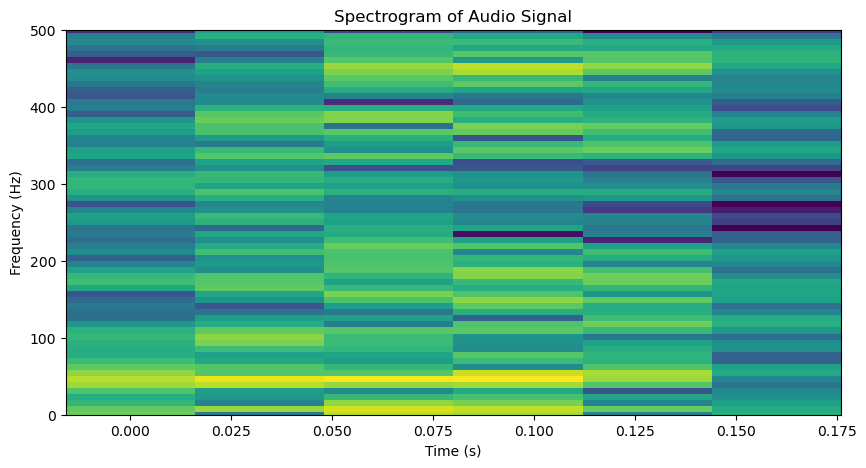

In [33]:
plot_spectrogram(f_win, t_win, Zxx_window[2324], 1000)